<a href="https://colab.research.google.com/github/judytang3103-port/vn-index-sector-analysis/blob/main/VN_Index_Sector_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sector Driver Analysis - VN-Index


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 140)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

def label_last_point(ax, series, label, color=None, x_offset=6):
    """Add a readable label beside the final non-missing point in a time series plot."""
    clean = series.dropna()
    if clean.empty:
        return
    ax.annotate(
        label,
        xy=(clean.index[-1], clean.iloc[-1]),
        xytext=(x_offset, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=color,
    )

market_file = "VN Index.csv"
stock_files = ["FPT.csv", "MSN.csv", "STB.csv", "VCB.csv", "VHM.csv", "VNM.csv", "NVL.csv"]
risk_free_rate = 0.0
trading_days = 252

##Market Performance

In [ ]:
# Load VN Index data
vnindex = pd.read_csv(market_file)
vnindex["Date"] = pd.to_datetime(vnindex["Date"], dayfirst=True)
vnindex["Last"] = vnindex["Last"].astype(str).str.replace(",", "", regex=False).astype(float)
vnindex = vnindex.sort_values("Date")

P_m = vnindex.set_index("Date")["Last"].dropna()
r_m = np.log(P_m / P_m.shift(1)).dropna()

vnindex.head()

,Date,Last,Open,High,Low,Vol.,Change %
1749,2018-12-28,892.55,NaN,NaN,NaN,NaN,NaN
1748,2019-01-02,891.75,900.10,900.10,891.10,111520,-0.09%
1747,2019-01-03,878.22,889.78,892.21,872.12,156580,-1.52%
1746,2019-01-04,880.90,872.69,881.48,861.85,136570,0.31%
1745,2019-01-07,889.64,890.47,896.63,885.30,127550,0.99%


Date        datetime64[ns]
Last               float64
Open                object
High                object
Low                 object
Vol.                object
Change %            object
dtype: object


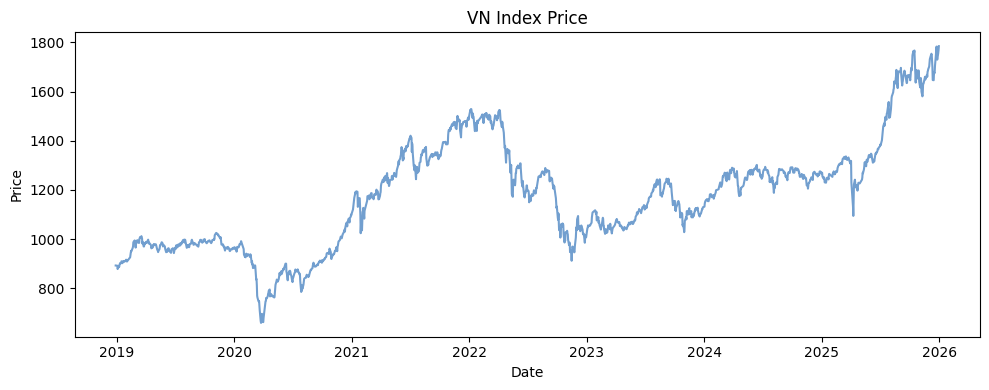

In [ ]:
# Clean VN Index data
vnindex["Date"] = pd.to_datetime(vnindex["Date"], dayfirst=True)
vnindex["Last"] = vnindex["Last"].astype(str).str.replace(",", "", regex=False).astype(float)
vnindex = vnindex.sort_values("Date")

print(vnindex.dtypes)
vnindex[["Date", "Last"]].head()

# Create the VN Index price series
P_m = vnindex.set_index("Date")["Last"].dropna()
P_m.head()

# Plot VN Index prices
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(P_m.index, P_m.values, color="#729fcf", label="VN Index closing price")
label_last_point(ax, P_m, "VN Index", color="#4f7fb7")
ax.set_title("VN Index Closing Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (Index Points)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

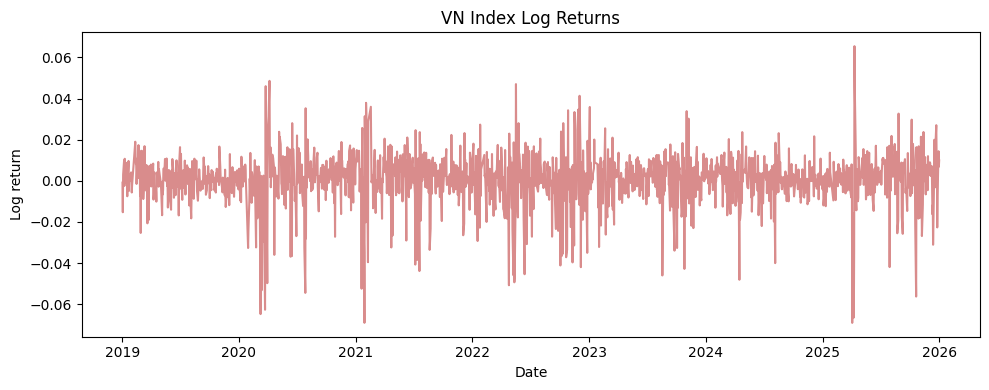

In [ ]:
# Calculate VN Index log returns
r_m = np.log(P_m / P_m.shift(1))
r_m = r_m.dropna()

r_m.head()

# Plot VN Index returns
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_m.index, r_m.values, color="#d98c8c", label="VN Index daily log return")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6, label="Zero return")
ax.set_title("VN Index Daily Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Log Return")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

In [ ]:
# Summary statistics for VN Index returns
def describe(r_m):
    return pd.Series({
    "Mean": r_m.mean(),
    "Std Dev": r_m.std(),
    'Skewness': stats.skew(r_m),
    'Kurtosis': stats.kurtosis(r_m),
    "Min": r_m.min(),
    "Max": r_m.max()
})

desc_r = describe(r_m)
description_df = pd.DataFrame(desc_r)
description_df.columns = ['VN-index']
display(description_df)

,VN-index
Mean,0.000396
Std Dev,0.012261
Skewness,-1.064886
Kurtosis,5.582948
Min,-0.069102
Max,0.065469


##Sector Performance

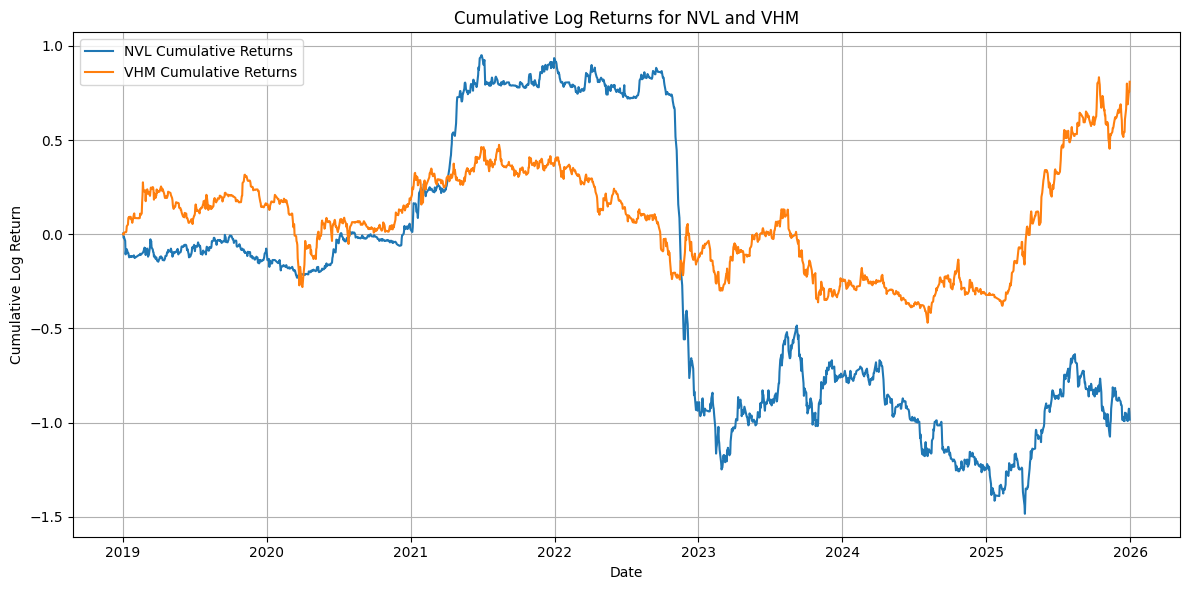

In [ ]:
# Build stock return series
stock_returns = {}

for file in stock_files:
    stock = pd.read_csv(file)
    stock["Date"] = pd.to_datetime(stock["Date"], dayfirst=True)
    stock["Last"] = stock["Last"].astype(str).str.replace(",", "", regex=False).astype(float)
    stock = stock.sort_values("Date")

    stock_name = file.replace(".csv", "")
    P_i = stock.set_index("Date")["Last"].dropna()
    r_i = np.log(P_i / P_i.shift(1)).dropna()
    stock_returns[stock_name] = r_i

list(stock_returns.keys())

# Calculate cumulative returns for NVL and VHM
nvl_returns = stock_returns["NVL"].cumsum()
vhm_returns = stock_returns["VHM"].cumsum()

# Plot cumulative returns
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(nvl_returns.index, nvl_returns, label="NVL cumulative log return", color="#e76f51")
ax.plot(vhm_returns.index, vhm_returns, label="VHM cumulative log return", color="#2a9d8f")
label_last_point(ax, nvl_returns, "NVL", color="#e76f51")
label_last_point(ax, vhm_returns, "VHM", color="#2a9d8f")

ax.set_title("Cumulative Log Returns: NVL vs VHM")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

In [ ]:
sector_weights = {
    "Banking": {"VCB": 0.5786, "STB": 0.4214},
    "Consumer Staples": {"MSN": 0.5520, "VNM": 0.4480},
    "Real Estate": {"VHM": 0.6825, "NVL": 0.3175},
    "Info Tech": {"FPT": 1.0000}
}

#Sector return series with value-weighted returns (DAILY)
sector_returns = pd.DataFrame()

for sector, weights in sector_weights.items():
    sector_data = pd.DataFrame()

    for stock_name, weight in weights.items():
        sector_data[stock_name] = stock_returns[stock_name]

    sector_data = sector_data.dropna()
    sector_returns[sector] = sum(weight * sector_data[stock_name] for stock_name, weight in weights.items())

sector_returns.head()

,Banking,Consumer Staples,Real Estate,Info Tech
Date,,,,
2019-01-02,-0.011433,0.022455,0.002433,-0.023986
2019-01-03,-0.018567,-0.008223,-0.010273,-0.009755
2019-01-04,0.010461,-0.005299,0.008438,0.007329
2019-01-07,0.015153,0.035308,-0.004253,0.016882
2019-01-08,-0.001312,0.002183,-0.022820,0.004773


In [ ]:
sector_summary = pd.DataFrame({
    "Mean Return": sector_returns.mean(),
    "Std Dev": sector_returns.std(),
    "Skewness": sector_returns.skew(),
    "Kurtosis": sector_returns.kurtosis(),
    "Annualised Return": sector_returns.mean() * trading_days,
    "Annualised Volatility": sector_returns.std() * np.sqrt(trading_days)
})

sector_summary["Sharpe Ratio"] = (
    (sector_summary["Annualised Return"] - risk_free_rate)
    / sector_summary["Annualised Volatility"]
)

sector_summary.style.format({
    "Mean Return": "{:.2%}",
    "Std Dev": "{:.2%}",
    "Skewness": "{:.2f}",
    "Kurtosis": "{:.2f}",
    "Annualised Return": "{:.2%}",
    "Annualised Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
})


,Mean Return,Std Dev,Skewness,Kurtosis,Annualised Return,Annualised Volatility,Sharpe Ratio
Banking,0.05%,1.71%,-1.95,23.52,12.39%,27.15%,0.46
Consumer Staples,-0.01%,1.59%,-0.50,4.33,-2.82%,25.17%,-0.11
Real Estate,0.01%,1.79%,-0.09,2.39,3.46%,28.36%,0.12
Info Tech,0.11%,1.72%,-0.12,3.27,28.03%,27.34%,1.02


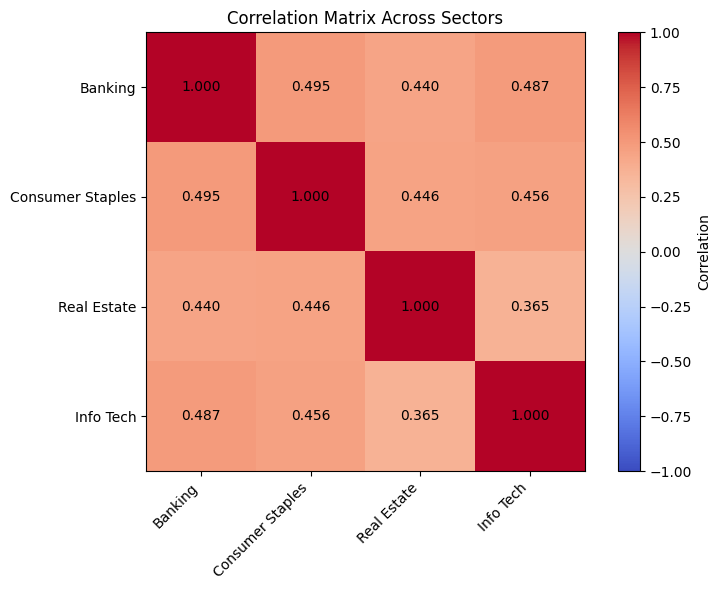

In [ ]:
# Correlation matrix across sectors
sector_correlation = sector_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(sector_correlation, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(image, ax=ax, label="Correlation Coefficient")
ax.set_xticks(range(len(sector_correlation.columns)))
ax.set_xticklabels(sector_correlation.columns, rotation=45, ha="right")
ax.set_yticks(range(len(sector_correlation.index)))
ax.set_yticklabels(sector_correlation.index)

for i in range(len(sector_correlation.index)):
    for j in range(len(sector_correlation.columns)):
        ax.text(j, i, f"{sector_correlation.iloc[i, j]:.3f}", ha="center", va="center", color="black")

ax.set_title("Correlation Matrix Across Sector Daily Returns")
ax.set_xlabel("Sector")
ax.set_ylabel("Sector")
fig.tight_layout()
plt.show()

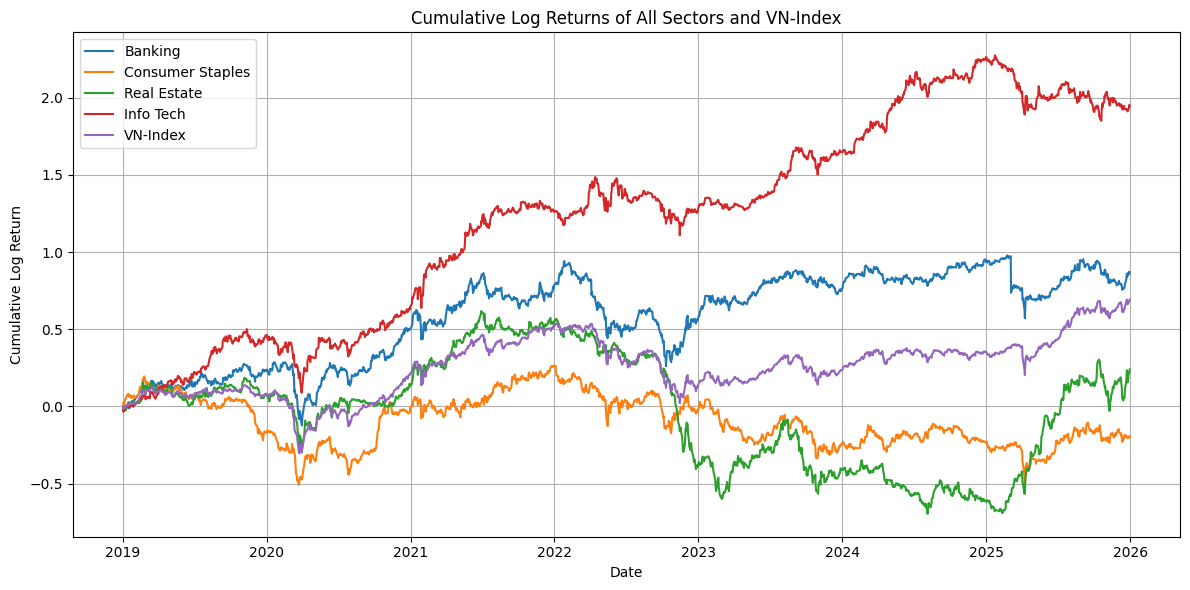

In [ ]:
# Combine sector returns and VN-Index returns into a single DataFrame
all_returns = pd.concat([sector_returns, r_m.rename("VN-Index")], axis=1)

# Calculate cumulative log returns
cumulative_log_returns = all_returns.cumsum()

# Plot cumulative log returns
fig, ax = plt.subplots(figsize=(12, 6))
for column in cumulative_log_returns.columns:
    ax.plot(cumulative_log_returns.index, cumulative_log_returns[column], label=column)
    label_last_point(ax, cumulative_log_returns[column], column)

ax.set_title("Cumulative Log Returns: Sectors and VN Index")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.legend(loc="best", ncol=2)
fig.tight_layout()
plt.show()

##Correlation Dynamics

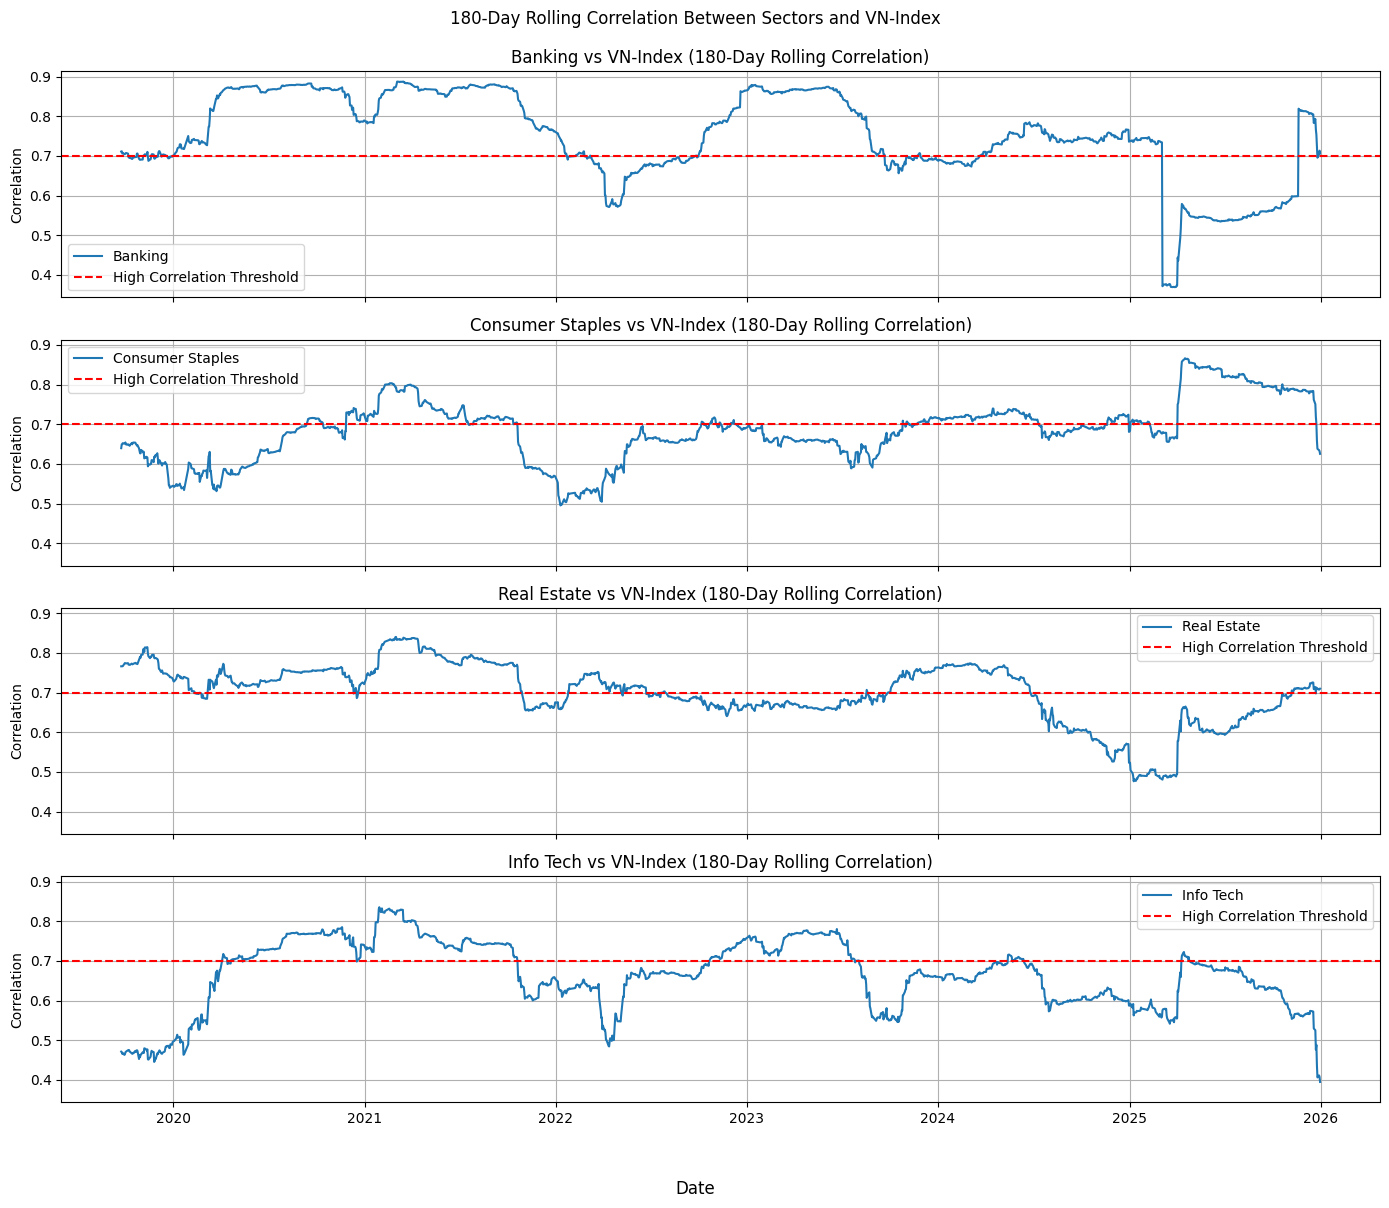

In [ ]:
window = 180
rolling_correlations = pd.DataFrame()

# Calculate rolling correlation for each sector against VN-Index
for sector in sector_returns.columns:
    rolling_correlations[sector] = all_returns[sector].rolling(window=window).corr(all_returns["VN-Index"])

# Plot rolling correlations as separate subplots
fig, axes = plt.subplots(nrows=len(sector_returns.columns), ncols=1, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, sector in enumerate(sector_returns.columns):
    axes[i].plot(rolling_correlations.index, rolling_correlations[sector], label=f"{sector} vs VN Index")
    axes[i].set_title(f"{sector}: {window}-Day Rolling Correlation with VN Index")
    axes[i].set_ylabel("Correlation")
    axes[i].axhline(y=0.7, color="red", linestyle="--", linewidth=1, label="High correlation threshold (0.70)")
    axes[i].axhline(y=0, color="black", linewidth=0.8, alpha=0.35)
    axes[i].legend(loc="best")

fig.supxlabel("Date")
fig.suptitle(f"{window}-Day Rolling Correlation Between Sectors and VN Index", y=1.00)
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

##Regression Models

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

sector_regression_data = {}

for sector in sector_returns.columns:
    data = pd.concat([sector_returns[sector], r_m], axis=1, join="inner").dropna()
    data.columns = ["R_sector", "R_market"]

    data["R_market_lag1"] = data["R_market"].shift(1)
    data["R_sector_lag1"] = data["R_sector"].shift(1)
    data = data.dropna()

    sector_regression_data[sector] = data

sector_regression_data.keys()


dict_keys(['Banking', 'Consumer Staples', 'Real Estate', 'Info Tech'])

### Simple Linear Regression

In [ ]:
slr_results = {}

for sector, data in sector_regression_data.items():
    X = sm.add_constant(data[["R_market"]])
    y = data["R_sector"]

    model = sm.OLS(y, X).fit()
    slr_results[sector] = model.rsquared

slr_df = pd.DataFrame({
    "Sector": list(slr_results.keys()),
    "SLR R²": list(slr_results.values())
})

slr_df


,Sector,SLR R²
0,Banking,0.565351
1,Consumer Staples,0.469032
2,Real Estate,0.478338
3,Info Tech,0.431613


### Multiple Linear Regression with Lagged Sector and Market Returns

In [ ]:
mlr_bothlags_results = {}

for sector, data in sector_regression_data.items():
    X = sm.add_constant(data[["R_market", "R_market_lag1", "R_sector_lag1"]])
    y = data["R_sector"]

    model = sm.OLS(y, X).fit()
    mlr_bothlags_results[sector] = model.rsquared

mlr_bothlags_df = pd.DataFrame({
    "Sector": list(mlr_bothlags_results.keys()),
    "MLR_BothLags R²": list(mlr_bothlags_results.values())
})

mlr_bothlags_df


,Sector,MLR_BothLags R²
0,Banking,0.566532
1,Consumer Staples,0.470125
2,Real Estate,0.490265
3,Info Tech,0.438070


### Ridge Regression

In [ ]:
ridge_results = {}

for sector, data in sector_regression_data.items():
    X = data[["R_market", "R_market_lag1", "R_sector_lag1"]]
    y = data["R_sector"]

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    ridge_results[sector] = r2_score(y, y_pred)

ridge_df = pd.DataFrame({
    "Sector": list(ridge_results.keys()),
    "Ridge R²": list(ridge_results.values())
})

ridge_df


,Sector,Ridge R²
0,Banking,0.566532
1,Consumer Staples,0.470125
2,Real Estate,0.490265
3,Info Tech,0.438070


### Lasso Regression

In [ ]:
lasso_results = {}

for sector, data in sector_regression_data.items():
    X = data[["R_market", "R_market_lag1", "R_sector_lag1"]]
    y = data["R_sector"]

    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.0001)
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    lasso_results[sector] = r2_score(y, y_pred)

lasso_df = pd.DataFrame({
    "Sector": list(lasso_results.keys()),
    "Lasso R²": list(lasso_results.values())
})

lasso_df


,Sector,Lasso R²
0,Banking,0.566399
1,Consumer Staples,0.469819
2,Real Estate,0.490023
3,Info Tech,0.437839


In [ ]:
comparison_df = pd.DataFrame({
    "Sector": list(sector_regression_data.keys()),
    "SLR R²": [slr_results[s] for s in sector_regression_data.keys()],
    "MLR_BothLags R²": [mlr_bothlags_results[s] for s in sector_regression_data.keys()],
    "Lasso R²": [lasso_results[s] for s in sector_regression_data.keys()],
    "Ridge R²": [ridge_results[s] for s in sector_regression_data.keys()]
})

comparison_df
comparison_df.style.format({
    "SLR R²": "{:.4f}",
    "MLR_BothLags R²": "{:.4f}",
    "Lasso R²": "{:.4f}",
    "Ridge R²": "{:.4f}"
})

,Sector,SLR R²,MLR_BothLags R²,Lasso R²,Ridge R²
0,Banking,0.5654,0.5665,0.5664,0.5665
1,Consumer Staples,0.4690,0.4701,0.4698,0.4701
2,Real Estate,0.4783,0.4903,0.4900,0.4903
3,Info Tech,0.4316,0.4381,0.4378,0.4381


### Selected Model: MLR with Current and Lagged Log Returns

In [ ]:
import statsmodels.api as sm

mlr_bothlags_results = {}

for sector, data in sector_regression_data.items():
    X = sm.add_constant(data[["R_market", "R_market_lag1", "R_sector_lag1"]])
    y = data["R_sector"]

    model = sm.OLS(y, X).fit()
    mlr_bothlags_results[sector] = model

mlr_bothlags_table = []

for sector, model in mlr_bothlags_results.items():
    mlr_bothlags_table.append({
        "Sector": sector,
        "Alpha": model.params["const"],
        "Beta (R_market)": model.params["R_market"],
        "Beta (R_market_lag1)": model.params["R_market_lag1"],
        "Beta (R_sector_lag1)": model.params["R_sector_lag1"],
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Alpha p-value": model.pvalues["const"],
        "Market p-value": model.pvalues["R_market"],
        "Market Lag p-value": model.pvalues["R_market_lag1"],
        "Sector Lag p-value": model.pvalues["R_sector_lag1"]
    })

mlr_bothlags_df = pd.DataFrame(mlr_bothlags_table)
mlr_bothlags_df


,Sector,Alpha,Beta (R_market),Beta (R_market_lag1),Beta (R_sector_lag1),R²,Adj R²,Alpha p-value,Market p-value,Market Lag p-value,Sector Lag p-value
0,Banking,0.000098,1.052783,-0.059107,0.011622,0.566532,0.565787,0.716138,1.622492e-318,0.077700,6.275026e-01
1,Consumer Staples,-0.000456,0.886179,-0.038723,0.045338,0.470125,0.469214,0.099312,1.641184e-241,0.211866,5.809300e-02
2,Real Estate,-0.000233,1.006320,-0.124001,0.149183,0.490265,0.489388,0.445417,3.588715e-251,0.000342,3.749360e-10
3,Info Tech,0.000773,0.929579,-0.139334,0.035363,0.438070,0.437104,0.012733,2.743482e-219,0.000033,1.377833e-01


In [ ]:
mlr_bothlags_df.style.format({
    "Beta (R_market)": "{:.4f}",
    "Beta (R_market_lag1)": "{:.4f}",
    "Beta (R_sector_lag1)": "{:.4f}",
    "R²": "{:.4f}",
    "Adj R²": "{:.4f}",
    "Alpha p-value": "{:.4f}",
    "Market p-value": "{:.4f}",
    "Market Lag p-value": "{:.4f}",
    "Sector Lag p-value": "{:.4f}"
})

,Sector,Alpha,Beta (R_market),Beta (R_market_lag1),Beta (R_sector_lag1),R²,Adj R²,Alpha p-value,Market p-value,Market Lag p-value,Sector Lag p-value
0,Banking,0.000098,1.0528,-0.0591,0.0116,0.5665,0.5658,0.7161,0.0000,0.0777,0.6275
1,Consumer Staples,-0.000456,0.8862,-0.0387,0.0453,0.4701,0.4692,0.0993,0.0000,0.2119,0.0581
2,Real Estate,-0.000233,1.0063,-0.1240,0.1492,0.4903,0.4894,0.4454,0.0000,0.0003,0.0000
3,Info Tech,0.000773,0.9296,-0.1393,0.0354,0.4381,0.4371,0.0127,0.0000,0.0000,0.1378


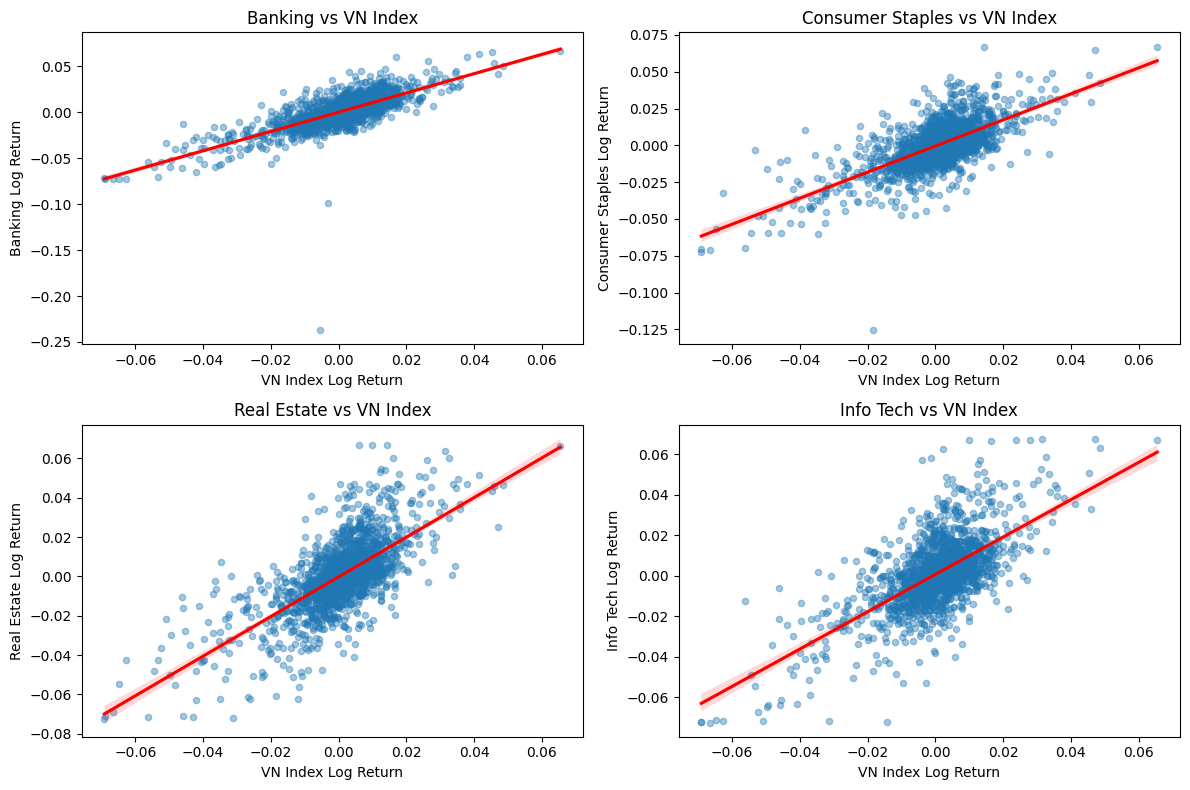

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, sector in zip(axes, sector_returns.columns):
    regression_data = pd.concat([sector_returns[sector], r_m], axis=1, join="inner").dropna()
    regression_data.columns = ["R_sector", "R_market"]

    sns.regplot(
        data=regression_data,
        x="R_market",
        y="R_sector",
        ax=ax,
        scatter_kws={"alpha": 0.4, "s": 20},
        line_kws={"color": "red", "label": "OLS fit"},
    )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.3)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.3)
    ax.set_title(f"{sector}: Sector Return vs VN Index Return")
    ax.set_xlabel("VN Index Daily Log Return")
    ax.set_ylabel(f"{sector} Daily Log Return")
    ax.legend(loc="best")

fig.suptitle("Regression Scatterplots with Fitted Lines", y=1.02)
fig.tight_layout()
plt.show()

## Volatility Analysis

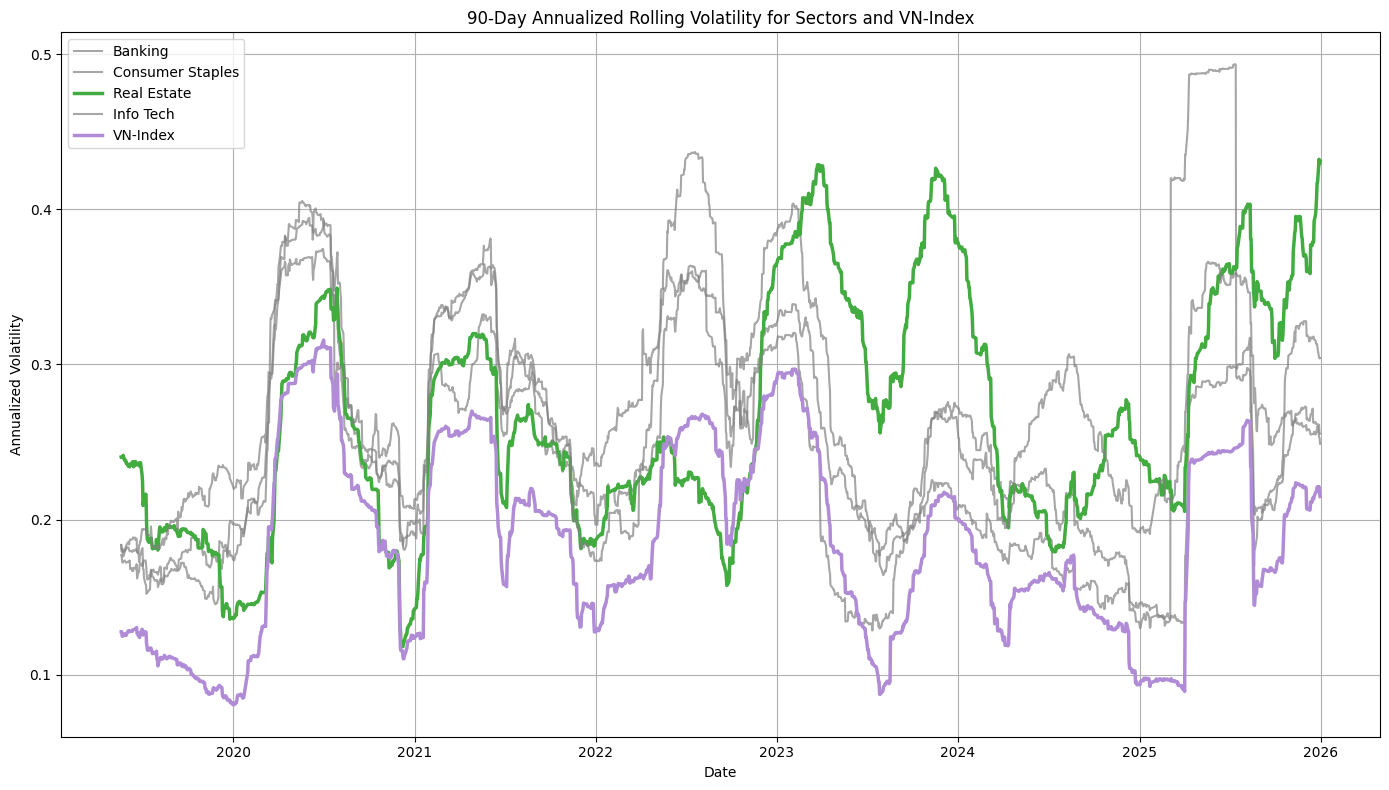

In [ ]:
window = 90

# Calculate rolling standard deviation for all returns
rolling_volatility = all_returns.rolling(window=window).std()

# Annualize the rolling volatility
annualized_rolling_volatility = rolling_volatility * np.sqrt(trading_days)

# Plot rolling volatilities with VN-Index and Real Estate highlighted
fig, ax = plt.subplots(figsize=(14, 8))
for column in annualized_rolling_volatility.columns:
    if column == "VN-Index":
        ax.plot(annualized_rolling_volatility.index, annualized_rolling_volatility[column], label="VN Index", color="#b08cd6", linewidth=2.5)
        label_last_point(ax, annualized_rolling_volatility[column], "VN Index", color="#8a62bd")
    elif column == "Real Estate":
        ax.plot(annualized_rolling_volatility.index, annualized_rolling_volatility[column], label="Real Estate sector", color="#43ac41", linewidth=2.5)
        label_last_point(ax, annualized_rolling_volatility[column], "Real Estate", color="#2f8f2d")
    else:
        ax.plot(annualized_rolling_volatility.index, annualized_rolling_volatility[column], label=column, color="gray", alpha=0.7)

ax.set_title(f"{window}-Day Annualized Rolling Volatility: Sectors and VN Index")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend(loc="best", ncol=2)
fig.tight_layout()
plt.show()